# PulseFit — Weekly Calorie Estimator
### Session notebook · Supervised Learning in practice (KNN & Decision Trees)

We received one email from **PulseFit** (see the brief). In plain business language it asks
for a new app feature that shows each member an **estimate of the calories they'll burn in a
coming week** — and it warns that a trainer damaged the data, so we must clean it first.

**Translating the request into ML terms**

- The thing we predict (calories/week) is a **number on a continuous scale** → this is a
  **regression** task (not classification).
- **Target (y):** `WeeklyCaloriesBurned`
- **Features (X):** `WorkoutsPerWeek`, `AvgSessionMinutes`, `Age`, `Weight_kg`, `BMI`,
  `Gender`, `MembershipType`, `FitnessGoal`
- **Two methods to compare:** a **Decision Tree** and **K-Nearest Neighbours (KNN)** — then
  recommend one, with reasons.

**Roadmap:** load → **inspect** (unusual values · missing · duplicates) → **clean each** →
Decision Tree (+ plot, tune `max_depth`) → prepare data for KNN → KNN (tune `k`) → compare.

> ### ❓ Warm-up — from the session (supervised_learning slides, p.1–14)
> Answer these from the presentation before you run any code.
>
> 1. The deck opens with *search* (BFS, DFS, A*) before *learning*. In one sentence, what is
> 2. the core difference between **search & optimisation** and **machine learning**?
> 3. What makes a problem **supervised**?  with an example.
> 4. Name the **main steps** of the ML workflow 
> 5. Of the four main tasks (classification, regression, clustering, anomaly detection), which
>   **two are supervised**, and how do **classification** and **regression** differ?
> . Our task predicts a number of calories. Which of the four tasks is it, and why?

1: The core difference is how the solution is reached: search and optimisation look for the best solution directly using a known objective function, while machine learning learns patterns from data so it can generalise to new, unseen examples.

2: A problem is supervised when it needs "labeled" examples — inputs paired with the correct output (target) — so the model can learn from them, like training on emails already marked as spam or not.

3: The main steps of the ML workflow are: prepare the data > train the model > test/evaluate it > predict on new data.

4: Classification and regression are the two supervised tasks; classification predicts a category, while regression predicts a numerical value. For our task of predicting a number of calories, we use regression, since calories are a continuous number rather than a category.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 4.5)

## 2. Load the data

In [2]:
df = pd.read_csv("D:\\AI\\MasterClass\\Homeworks\\2nd_homework\\dataset.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (4045, 13)


,MemberID,JoinDate,Gender,Age,MembershipType,FitnessGoal,Height_cm,Weight_kg,BMI,WorkoutsPerWeek,AvgSessionMinutes,WeeklyCaloriesBurned,RestingHeartRate
0,13635,2024-05-18,Male,26,Standard,Muscle Gain,175.7,78.5,25.4,6.0,65.0,3225,72.0
1,10150,2024-08-13,Male,25,Basic,Endurance,187.2,88.7,25.3,4.0,20.0,792,64.0
2,12511,2024-10-28,Male,25,Bsaic,Muscle Gain,180.6,75.7,23.2,3.0,71.0,1681,68.0
3,12507,2023-09-27,Male,39,Basic,Muscle Gain,180.5,76.3,23.4,0.0,46.0,0,78.0
4,13205,2023-02-17,Female,36,Basic,Muscle Gain,171.5,64.3,21.9,0.0,28.0,0,73.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4045 entries, 0 to 4044
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MemberID              4045 non-null   int64  
 1   JoinDate              4045 non-null   str    
 2   Gender                4015 non-null   str    
 3   Age                   4024 non-null   str    
 4   MembershipType        4020 non-null   str    
 5   FitnessGoal           4023 non-null   str    
 6   Height_cm             4025 non-null   float64
 7   Weight_kg             3983 non-null   str    
 8   BMI                   4009 non-null   float64
 9   WorkoutsPerWeek       4020 non-null   float64
 10  AvgSessionMinutes     3995 non-null   float64
 11  WeeklyCaloriesBurned  4045 non-null   int64  
 12  RestingHeartRate      3999 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 566.8 KB


> **Notice:** some columns that should be numbers (like `Age`, `Weight_kg`) are stored as
> `object` (text). That already hints the trainer typed text into number columns.

## 3. Inspect the damage (look only — don't fix yet)

The email mentioned three kinds of problem. We check for each **before** touching anything.

### 3.1 Unusual / impossible values

In [4]:
# Temporarily read the number columns as numbers so we can see their real range.
num_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "WorkoutsPerWeek",
            "AvgSessionMinutes", "WeeklyCaloriesBurned", "RestingHeartRate"]
peek = df.copy()
for c in num_cols:
    peek[c] = pd.to_numeric(peek[c], errors="coerce")

print("Min / max of each numeric column:")
display(peek[num_cols].describe().T[["min", "max"]])

print("\nCategory labels actually present:")
for c in ["Gender", "MembershipType", "FitnessGoal"]:
    print(f"  {c}: {sorted(df[c].dropna().unique().tolist())}")

Min / max of each numeric column:


,min,max
Age,-5.00,400.0
Height_cm,1.68,999.0
Weight_kg,-80.00,950.0
BMI,-20.00,999.0
WorkoutsPerWeek,-2.00,99.0
AvgSessionMinutes,-45.00,5000.0
WeeklyCaloriesBurned,-1200.00,99999.0
RestingHeartRate,-60.00,400.0



Category labels actually present:
  Gender: [' Male', 'F', 'FEMALE', 'Femal', 'Female', 'M', 'MALE', 'Male', 'Male ', 'female', 'male']
  MembershipType: [' Premium', 'Basic', 'Basic ', 'Bsaic', 'PREMIUM', 'Premium', 'Standard', 'Standrd', 'basic', 'premium', 'standard']
  FitnessGoal: [' Endurance', 'Endurance', 'General Fitness', 'Genral Fitness', 'MUSCLE GAIN', 'Muscle Gain', 'Weight  Loss', 'Weight Loss', 'endurance', 'general fitness', 'weight loss']


> ### ❓ Read the output above
> 1. Name **three** numeric values here that are impossible for a real gym member.
> 2. The category columns should have only a few clean labels each. List the kinds of mess
>    you can see (think: capitalisation, spelling, extra spaces).

All clearly demonstrate the problem. The dataset actually contains many such suspicious ranges, including Age -5 to 400, Weight -80 to 950, and WeeklyCaloriesBurned -1200 to 99999.
for the categorical columns 
capitalization: male vs Male
spelling: Femal
spaces: ' Endurance'

### 3.2 Missing values

In [5]:
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))
print("\nTotal blank cells:", int(df.isna().sum().sum()))

Weight_kg            62
AvgSessionMinutes    50
RestingHeartRate     46
BMI                  36
Gender               30
MembershipType       25
WorkoutsPerWeek      25
FitnessGoal          22
Age                  21
Height_cm            20
dtype: int64

Total blank cells: 337


> ### ❓ Read the output above
> 1. Which **three** columns have the most missing values?
> 2. Once we convert the text-in-number columns to real numbers, will the number of missing
>    cells go **up or down**? Why?

1. Columns with most missing values:
weight_kg, AvgSession, RestingHeartRate
2. Converting text-in-number columns  makes all hidden missing values that were disguised as text visible, so isnull().sum() shows an increase in total missing values.

### 3.3 Duplicate rows

In [6]:
print("Exact duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values("MemberID").head(6)

Exact duplicate rows: 45


,MemberID,JoinDate,Gender,Age,MembershipType,FitnessGoal,Height_cm,Weight_kg,BMI,WorkoutsPerWeek,AvgSessionMinutes,WeeklyCaloriesBurned,RestingHeartRate
1037,10143,2023-01-05,Female,57,Basic,Weight Loss,162.1,58.3,22.2,2.0,41.0,515,79.0
2151,10143,2023-01-05,Female,57,Basic,Weight Loss,162.1,58.3,22.2,2.0,41.0,515,79.0
2200,10378,2024-03-24,Male,41,Basic,General Fitness,180.2,74.1,22.8,5.0,49.0,1918,65.0
3702,10378,2024-03-24,Male,41,Basic,General Fitness,180.2,74.1,22.8,5.0,49.0,1918,65.0
3458,10513,2023-01-05,Female,36,Premium,Muscle Gain,167.2,59.5,21.3,5.0,56.0,1639,73.0
2494,10513,2023-01-05,Female,36,Premium,Muscle Gain,167.2,59.5,21.3,5.0,56.0,1639,73.0


> ### ❓ Read the output above
> How many duplicate rows are there? If we leave them in, in which direction could they bias
> the model — toward the members who appear **once**, or the members who appear **twice**?

45 exact duplicate rows.
Direction of bias: toward the members who appear twice.

## 4. Clean each problem — one at a time

We handle the three problems in separate, clearly labelled steps so the work is auditable.

### 4.1 Fix the unusual / impossible values

In [7]:
# (a) turn the number columns into real numbers; text junk ('N/A', '??') becomes NaN
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# (b) standardise the category text: strip spaces, unify case, fix typos
def clean_text(s):
    return s.astype("string").str.strip().str.lower().str.replace(r"\s+", " ", regex=True)

df["Gender"] = clean_text(df["Gender"]).map(
    {"male": "Male", "m": "Male", "female": "Female", "f": "Female", "femal": "Female"})
df["MembershipType"] = clean_text(df["MembershipType"]).map(
    {"basic": "Basic", "bsaic": "Basic", "standard": "Standard",
     "standrd": "Standard", "premium": "Premium"})
df["FitnessGoal"] = clean_text(df["FitnessGoal"]).map(
    {"weight loss": "Weight Loss", "muscle gain": "Muscle Gain",
     "endurance": "Endurance", "general fitness": "General Fitness",
     "genral fitness": "General Fitness"})

# (c) anything outside a plausible real-world range -> NaN (handled in the next step)
bounds = {"Age": (16, 80), "Height_cm": (130, 220), "Weight_kg": (35, 200),
          "BMI": (12, 50), "WorkoutsPerWeek": (0, 7), "AvgSessionMinutes": (10, 180),
          "WeeklyCaloriesBurned": (0, 8000), "RestingHeartRate": (35, 120)}
for c, (lo, hi) in bounds.items():
    n_bad = ((df[c] < lo) | (df[c] > hi)).sum()
    df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan
    if n_bad:
        print(f"{c:22s}: {n_bad} impossible value(s) -> NaN")

print("\nCategories after cleaning:")
for c in ["Gender", "MembershipType", "FitnessGoal"]:
    print(" ", c, "->", df[c].dropna().unique().tolist())

Age                   : 12 impossible value(s) -> NaN
Height_cm             : 10 impossible value(s) -> NaN
Weight_kg             : 8 impossible value(s) -> NaN
BMI                   : 8 impossible value(s) -> NaN
WorkoutsPerWeek       : 10 impossible value(s) -> NaN
AvgSessionMinutes     : 10 impossible value(s) -> NaN
WeeklyCaloriesBurned  : 9 impossible value(s) -> NaN
RestingHeartRate      : 8 impossible value(s) -> NaN

Categories after cleaning:
  Gender -> ['Male', 'Female']
  MembershipType -> ['Standard', 'Basic', 'Premium']
  FitnessGoal -> ['Muscle Gain', 'Endurance', 'Weight Loss', 'General Fitness']


> ### ❓ From the session + methodology
> 1. We turned impossible numbers into `NaN` instead of deleting the whole row. Why keep the
>    rest of that member's data?
> 2. `WeeklyCaloriesBurned = 0` is **allowed** (an inactive member) but `= -500` is not. How did the range check treat each?

1. We replace the impossible value with NaN so that we can keep the rest of the member's useful information and handle the missing value separately.
2. 0       → allowed
-500    → converted to NaN

### 4.2 Fix the missing values

In [8]:
# We must never invent the answer -> drop rows whose TARGET (y / class) is missing/invalid.
before = len(df)
df = df.dropna(subset=["WeeklyCaloriesBurned"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with no usable target.")

# Fill the remaining gaps in the FEATURES:
#   numeric  -> median (robust to outliers/skew)
#   category -> most frequent value (mode)
num_feats = ["WorkoutsPerWeek", "AvgSessionMinutes", "Age", "Weight_kg", "BMI"]
cat_feats = ["Gender", "MembershipType", "FitnessGoal"]

for c in num_feats + ["Height_cm", "RestingHeartRate"]:
    df[c] = df[c].fillna(df[c].median())
for c in cat_feats:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Missing cells left in our feature/target columns:",
      int(df[num_feats + cat_feats + ["WeeklyCaloriesBurned"]].isna().sum().sum()))

Dropped 9 rows with no usable target.
Missing cells left in our feature/target columns: 0


> ### ❓ Methodology — think it through
> 1. Why fill numeric gaps with the **median** rather than the **mean** here? 
> 2. Why is it a serious mistake to **impute the target** (`WeeklyCaloriesBurned`) the way we
>    impute a feature?

1. We use the median because it is less affected by extreme values and outliers than the mean.
2. We should not impute the target because it is the value we want the model to learn to predict. Inventing target values would create artificial labels and could bias the model.

### 4.3 Remove the duplicate rows

In [9]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows -> {len(df)} clean rows remain.")

# final check
print("Duplicates:", df.duplicated().sum(),
      "| Missing in model columns:",
      int(df[num_feats + cat_feats + ['WeeklyCaloriesBurned']].isna().sum().sum()))

Removed 45 duplicate rows -> 3991 clean rows remain.
Duplicates: 0 | Missing in model columns: 0


## 5. Features, target, and train/test split

We use the eight features the app will actually have, and hold out 20% of members to test on
data the model has never seen.

In [10]:
target = "WeeklyCaloriesBurned"
X = df[num_feats + cat_feats].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

def report(name, model_pred_train, model_pred_test):
    r2_tr = r2_score(y_train, model_pred_train)
    r2_te = r2_score(y_test, model_pred_test)
    print(f"{name}")
    print(f"  Train R2: {r2_tr:.3f}")
    print(f"  Test  R2: {r2_te:.3f}")
    return r2_te

Train: (3192, 8)  Test: (799, 8)


## 6. Model 1 — Decision Tree

A decision tree learns a flowchart of yes/no questions. As the slides note, a tree
**handles categories and needs no feature scaling** — so its data prep is minimal: we only
turn each category into a plain integer code so scikit-learn can read it.

> ### ❓ From the session — Decision Trees (slides p.34–38)
> 1. How does a tree choose which question to ask first? 
> 2. In the *Play Tennis* example, why is **Outlook** picked as the first split?
> 3. The deck says a single tree "easily overfits." What does it suggest to get more accuracy?

1. A decision tree chooses the split that gives the best reduction in impurity/error.
2. Outlook produces the greatest information gain / best impurity reduction, so it is selected as the first split.Outlook is the best first question: it decides 2 of the 3 groups instatntly
3. combine many trees for accuracy (random forests)

In [11]:
# Minimal prep for a tree: integer-code the categories (NO scaling, NO one-hot)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()
X_train_tree[cat_feats] = enc.fit_transform(X_train[cat_feats])
X_test_tree[cat_feats] = enc.transform(X_test[cat_feats])

# A first tree. max_depth=5 is just a starting point — you will tune it below.
tree = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train_tree, y_train)

tree_r2 = report("Decision Tree (max_depth=5)",
                           tree.predict(X_train_tree), tree.predict(X_test_tree))
for d in [3, 5, 8, 12, None]:
    t = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE).fit(X_train_tree, y_train)
    report(f"max_depth={d}", t.predict(X_train_tree), t.predict(X_test_tree))


Decision Tree (max_depth=5)
  Train R2: 0.928
  Test  R2: 0.904
max_depth=3
  Train R2: 0.822
  Test  R2: 0.822
max_depth=5
  Train R2: 0.928
  Test  R2: 0.904
max_depth=8
  Train R2: 0.982
  Test  R2: 0.953
max_depth=12
  Train R2: 0.999
  Test  R2: 0.953
max_depth=None
  Train R2: 1.000
  Test  R2: 0.950


### 6.1 Plot the tree

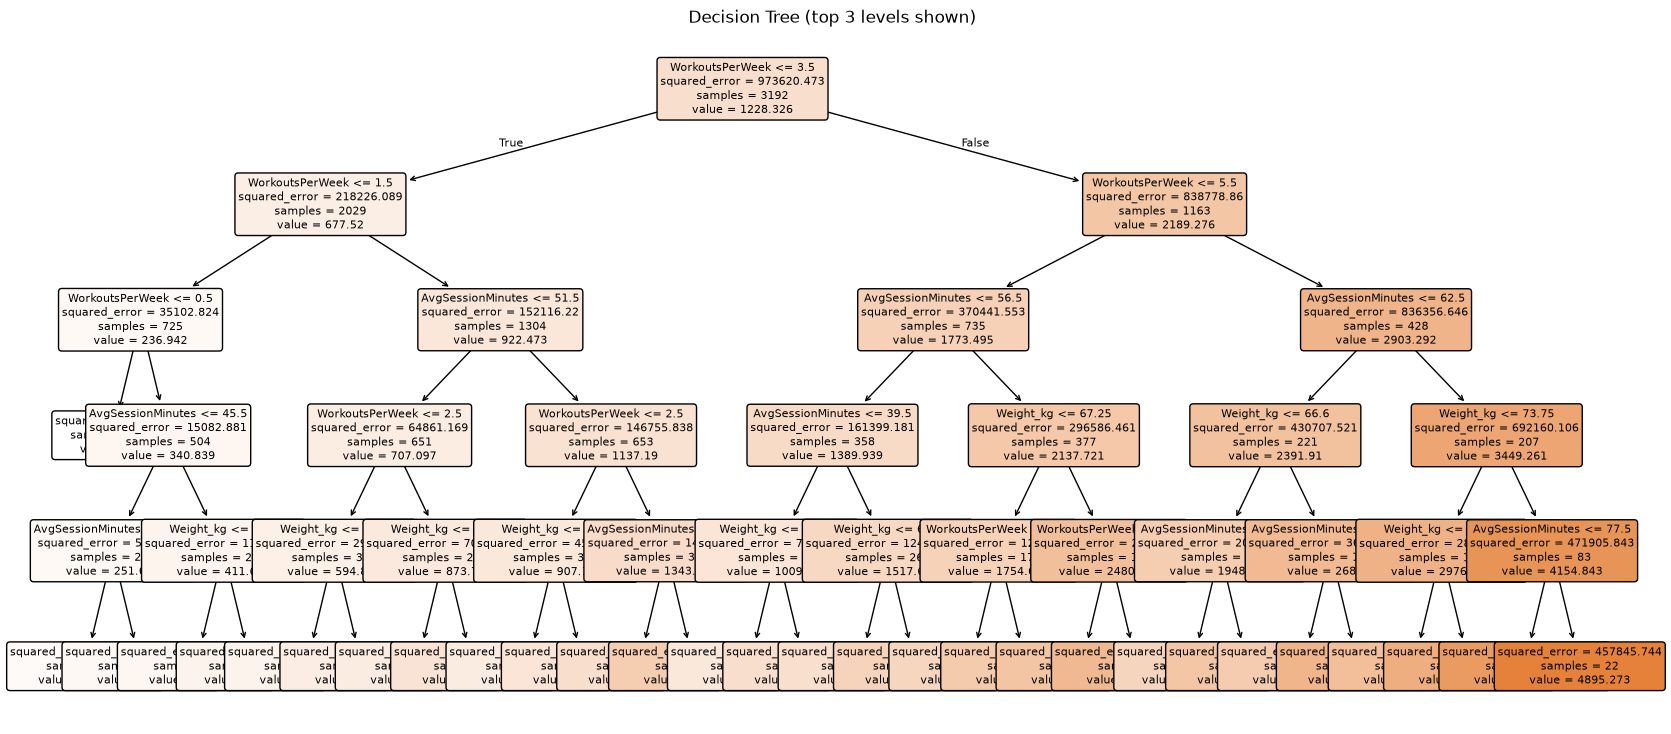

In [12]:
plt.figure(figsize=(20, 9))
plot_tree(tree, feature_names=list(X_train_tree.columns),
          filled=True, rounded=True, fontsize=8, max_depth=5)  
plt.title("Decision Tree (top 3 levels shown)")
plt.show()

> ### ❓ Read the tree
> 1. Which feature sits at the very **top (root)** of the tree? What does being the root split
>    tell you about how important that feature is for predicting calories?
> 2. Follow one path from the root to a leaf and describe, in words, the "member" that path
>    represents.

1. WorkoutsPerWeek was chosen as the first split because it provided the best separation of the data.
2.the extreme right; that member is really disciplned

### 6.2 🧪 YOUR EXPERIMENT — tune `max_depth`

The starting tree used `max_depth=5`. **Experiment with the `max_depth` variable and keep the
value that gives the best performance** on the test set.

In [21]:
# 🧪 TODO :
#   Try several depths, e.g. max_depth in [3, 5, 8, 12, None].
#   For EACH value:
#     - refit the tree on X_train_tree, y_train
#     - print Train R2 and Test R2 (use the report() helper)
#   Then KEEP the max_depth that gives the best TEST R2.
#
#   Watch the gap between Train R2 and Test R2 as depth grows:
#   when Train keeps rising but Test starts falling, the tree is OVERFITTING.
#
# Example to get you started (extend this into a loop):
best_depth = None
best_tree_r2 = -np.inf
best_tree = None

for d in [3, 5, 8, 12, None]:
    t = DecisionTreeRegressor(
        max_depth=d,
        random_state=RANDOM_STATE
    )
    
    t.fit(X_train_tree, y_train)
    
    train_pred = t.predict(X_train_tree)
    test_pred = t.predict(X_test_tree)
    
    test_r2 = report(
        f"max_depth={d}",
        train_pred,
        test_pred
    )
    
    if test_r2 > best_tree_r2:
        best_tree_r2 = test_r2
        best_depth = d
        best_tree = t

print("Best max_depth:", best_depth)
print("Best Test R²:", best_tree_r2)

max_depth=3
  Train R2: 0.822
  Test  R2: 0.822
max_depth=5
  Train R2: 0.928
  Test  R2: 0.904
max_depth=8
  Train R2: 0.982
  Test  R2: 0.953
max_depth=12
  Train R2: 0.999
  Test  R2: 0.953
max_depth=None
  Train R2: 1.000
  Test  R2: 0.950
Best max_depth: 8
Best Test R²: 0.9527279389798781


> ### ❓ After your experiment
> 1. Which `max_depth` gave the best **test** R²?
> 2. What happened to the **train vs test** gap at very large depth (or `None`)? What is that
>    behaviour called, and why is a deeper tree not always better?

1. max_depth 8 gave the best R² (smallest train-test gap.)
2. at a depth = None the train train R² becomes 1; (perfect moede), but in real world it's a red flag, the model memorises the trainig data, it's called overfitting

## 7. Prepare the data for KNN

KNN is different. It predicts by measuring **distance** to the nearest members, so the data
prep matters a lot:

- **One-hot encode** the categories — not integer codes. Integer codes would invent a fake
  order/distance (e.g. Basic=0, Standard=1, Premium=2 would make Premium "far" from Basic).
- **Standardise** the numeric features — so a large-range feature doesn't dominate the
  distance (exactly the warning on the KNN slide).

> ### ❓ From the session — KNN (slides p.23–33)
> 1. Why is KNN called a **"lazy"** learner? When does it actually do its work?
> 2. Write the **distance** formula. Why must features be **transformed(or scaled : normalized/standardized** first?
> 3. What does a **very small k** do to the predictions? A **very large k**? Why use an
>    **odd k**, and what starting value does the deck suggest?
> 4. For **regression**, how does KNN turn the k neighbours into a prediction (vs classification)?

1. KNN called a lazy learner because it does all its real work at prediction time
2. d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}, Ensure  features are on the same scale; if not, variables with wider ranges will overshadow the others when calculating distances.
3. Small k: High variance, low bias (captures noise, risks overfitting).
Large k: Low variance, high bias (smooths out the boundary, risks underfitting).
4. While the neighbors identified remain the same, the method for summarizing them changes: classification uses a majority vote, whereas regression uses an average.

In [14]:
# One ColumnTransformer that scales numbers AND one-hot encodes categories.
knn_prep = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
])
# Peek at what the prepared data looks like (fit on train only -> no leakage)
prepared = knn_prep.fit_transform(X_train)
print("KNN input shape after scaling + one-hot:", prepared.shape,
      "(was", X_train.shape[1], "columns before)")

KNN input shape after scaling + one-hot: (3192, 14) (was 8 columns before)


> ### ❓ Methodology — the key contrast (write full sentences)
> 1. **Why did we standardise the data for KNN but not for the Decision Tree?**
> 2. **Why did we one-hot encode the categories for KNN, but only integer-code them for the tree? (scikit learn implementation of decision trees doesn't allow raw textual categories)**

1. KNN uses distances between observations, so features with larger numerical ranges can dominate the distance calculation. Standardization puts numerical features on a comparable scale. Decision Trees do not use distance calculations, so feature scaling is not necessary.
2. We one-hot encode categorical variables for KNN because KNN relies on numerical distances, and integer encoding would create an artificial order and distance between categories.

## 8. Model 2 — K-Nearest Neighbours

In [15]:
# Pipeline = preprocessing + model, so the scaling/encoding is applied correctly.
# n_neighbors=5 is just a starting point — you can tune k .
knn = Pipeline([("prep", knn_prep),
                ("model", KNeighborsRegressor(n_neighbors=5))])
knn.fit(X_train, y_train)

knn_r2 = report("KNN (k=5)", knn.predict(X_train), knn.predict(X_test))

KNN (k=5)
  Train R2: 0.941
  Test  R2: 0.926


### 8.1 🧪 YOUR EXPERIMENT — tune `k`

The starting model used `k = 5`. **Experiment with the `k` value and keep the one that gives
the best performance** on the test set.

In [22]:
# 🧪 TODO :
#   Try several values of k, e.g. k in [1, 3, 5, 11, 25, 51].
#   For EACH k:
#     - rebuild the pipeline with KNeighborsRegressor(n_neighbors=k)
#     - fit on the training data and print Test R2 (use report())
#   Then KEEP the k that gives the best TEST R2.
#
#   Remember from the slides: very small k = noisy/overfit,
#   very large k = too smooth/underfit. Look for the sweet spot.
#
# Example to get you started (extend this into a loop):
best_k = None
best_knn_r2 = -np.inf
best_knn = None

for k in [1, 3, 5, 11, 25, 51]:
    m = Pipeline([
        ("prep", knn_prep),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])
    
    m.fit(X_train, y_train)
    
    train_pred = m.predict(X_train)
    test_pred = m.predict(X_test)
    
    test_r2 = report(
        f"k={k}",
        train_pred,
        test_pred
    )
    
    if test_r2 > best_knn_r2:
        best_knn_r2 = test_r2
        best_k = k
        best_knn = m

print("Best k:", best_k)
print("Best Test R²:", best_knn_r2)

k=1
  Train R2: 1.000
  Test  R2: 0.852
k=3
  Train R2: 0.950
  Test  R2: 0.914
k=5
  Train R2: 0.941
  Test  R2: 0.926
k=11
  Train R2: 0.931
  Test  R2: 0.924
k=25
  Train R2: 0.922
  Test  R2: 0.918
k=51
  Train R2: 0.912
  Test  R2: 0.907
Best k: 5
Best Test R²: 0.9255449425690001


> ### ❓ After your experiment
> 1. Which **k** gave the best **test** R²?
> 2. What did **k = 1** do to the training score vs the test score? 

1. k = 5 gave the best test R²
2. valid for the train score (1 so it's logic) but made big gap with the test score 

## 9. Compare and recommend

Bring the two models together and answer the client's real question.

In [17]:
summary = pd.DataFrame({
    "Test R2":  [round(tree_r2, 3), round(knn_r2, 3)],
}, index=["Decision Tree (depth=5)", "KNN (k=5)"])
print("Baseline results (before your tuning):")
summary

Baseline results (before your tuning):


,Test R2
Decision Tree (depth=5),0.904
KNN (k=5),0.926


> ### ❓ From the session — measuring a regressor 
> 1. What does **R²** actually measure? What do **R² = 1**, **R² = 0**, and **R² < 0** each mean?
R² measures how well the model explains the variation in the target compared with simply predicting the mean.
R² = 1     → perfect
R² ≈ 0     → no better than mean baseline
R² < 0     → worse than mean baseline
> ### ❓ Final recommendation (use YOUR tuned models)
> After tuning `max_depth` and `k`, compare your **best** tree and **best** KNN on test R²,
> then write 3–4 sentences recommending **one** model for PulseFit to build into the app.
> Go beyond accuracy — think about what the slides listed as each model's strengths and
> weaknesses: **interpretability**, the need for **scaling**, and **prediction speed / memory**.

I recommend the Decision Tree for the PulseFit app because it achieved the higher test R² of 0.953 compared with 0.926 for KNN. The tree is also easier to interpret because its decisions can be represented as a sequence of understandable rules. Unlike KNN, it does not require feature scaling, and predictions are generally faster because the model does not need to calculate distances to the training set for every new member. I would use the tuned tree with max_depth=8 because it achieved the same test R² as depth 12 while being simpler.